In [2]:
import logging
logging.basicConfig(level=logging.INFO, format='%(levelname)s - %(asctime)s - %(message)s')

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import os
import re
import gc

from evaluate import load

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

from IPython.display import clear_output

use_vad = True
use_excl_dz = True
narr_cosine_sim_lim = 0.14
diag_cosine_sim_lim = 0.3

whisper_model = 'turbo'
silero_threshold = 0.5

whisper_config = {
    'beam_size': 7,
    'no_speech_threshold': 0.1,
    'condition_on_previous_text': True
}

os.chdir('..') # Override jupyter's working directory back to project root
import audiodescription_abusedetection.data_extraction as da
from audiodescription_abusedetection import stt, utils, plotting

diarization_model = stt.pyannote_model_name
embedding_model = "pyannote/embedding"

import warnings
warnings.filterwarnings("ignore")

# logging.getLogger("speechbrain").setLevel(logging.WARNING)
logging.getLogger("pyannote").setLevel(logging.WARNING)
logging.getLogger('pytorch_lightning').setLevel(logging.ERROR)
logging.getLogger('pytorch').setLevel(logging.ERROR)


# TODO: Create list of abandoned films and just delete to save space
# TODO: Create ground truth for Substance 

In [3]:
films_list_df = da.get_or_create_subtitles_df()

In [4]:
snippets_df = da.get_manual_snippet_timestamps()

In [4]:
config_list = []
for silero_threshold in [0.5]: # (0.4, 0.45, 0.5):
    for whisper_model in ['turbo']: # , 'large'
        for cosine_sim_lim in [0.2, 0.3, 0.4, 0.5, 0.8]: # np.arange(0.4, 1.2, 0.2): # 0.15, 0.2, 
            for beam_size in [7]:
                for speech_cond in [True]:
                    for no_speech_threshold in [0.1]: # , 0.2
                        for min_seg_sec in [0]: #np.arange(0, 0.6, 0.1):
                            config = {
                                'use_vad': use_vad,
                                'silero_threshold': silero_threshold,
                                'whisper_model': whisper_model,
                                'cosine_sim_lim': cosine_sim_lim,
                                'beam_size': beam_size,
                                'no_speech_threshold': no_speech_threshold,
                                'condition_on_previous_text': speech_cond,
                                'min_seg_sec': min_seg_sec
                            }
                            
                            config_list.append(config)

In [5]:
man_transcripts = [x for x in os.listdir(da.manual_transcript_dir) if x.endswith('.txt')]
movies = [utils.remove_ext(x) for x in man_transcripts]

In [ ]:
overwrite = True

for ii, movie_name in enumerate(['The Big Short']):
    mp3_filename = f'{movie_name}.mp3'

    vad_df_path = os.path.join(da.voice_activity_dir, f'{movie_name}-snippet-vad.parquet')
    seg_df_path = os.path.join(da.diarization_dir, f'{movie_name}-snippet-diarization.parquet')
    curr_transcript_fp = os.path.join(da.transcript_dir, f'{movie_name}-snippet-transcript.parquet')
    wav_filepath = os.path.join(da.trans_mp3_dir, f'{movie_name}_speech_only-snippet.wav')

    # If either diarization or transcript is missing, we'll need to generate the wav file
    if not os.path.exists(curr_transcript_fp) or not os.path.exists(seg_df_path) or overwrite:
        logging.info(f'{ii} \t/ {len(movies)} \t {movie_name}')
        stt.apply_silero_vad_to_wav(mp3_filename, wav_filepath, vad_df_path, silero_threshold=silero_threshold, snippets_df=snippets_df)
            
    # Only perform diarization if parquet doesn't exist
    if not os.path.exists(seg_df_path) or overwrite:
        stt.apply_diarization(movie_name, wav_filepath, diarization_model, seg_df_path, vad_df_path, use_excl_dz, device)

    # Narrator Cosine sim limit is set to 0 for exploration, so deletion/retranscription needs to occur if movies have already been transcribed
    # Only assess cosine similarity if it is missing
    seg_df = pd.read_parquet(seg_df_path)
    if not 'cosine_sim' in seg_df.columns:
        stt.add_pyannote_cosine_sim(seg_df_path, wav_filepath, min_seg_sec=0, device=device)

    # Only perform transcription if parquet doesn't exist
    if not os.path.exists(curr_transcript_fp) or overwrite:
        stt.transcribe_segments(curr_transcript_fp, seg_df_path, wav_filepath, whisper_model, whisper_config, 0, device)

    # Delete Wav File afterwards as they are quick to generate and consume too much space
    if os.path.exists(wav_filepath):
        os.remove(wav_filepath)
        
    gc.collect()
    torch.cuda.empty_cache()

INFO - 2025-10-21 09:33:54,595 - 0 	/ 9 	 The Dead Lands
INFO - 2025-10-21 09:33:54,596 - Applying Silero VAD to The Dead Lands
INFO - 2025-10-21 09:34:23,815 - Slicing up audio from The Dead Lands to speech only


AcceleratorError: CUDA error: unknown error
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [14]:
cer, wer = load('cer'), load('wer')
results = []
word_counts = []

for movie_name in movies:
    curr_transcript_fp = os.path.join(da.transcript_dir, f'{movie_name}-snippet-transcript.parquet')
    trans_df = pd.read_parquet(curr_transcript_fp)
    trans_df = trans_df[trans_df['text'].ne(' Thank you.')]

    with open(os.path.join(da.manual_transcript_dir, f'{movie_name}.txt')) as fileobj:
        raw_txt = fileobj.read()
    ref_txt = re.sub('[\.,"\?!:]', '', raw_txt).lower().replace('-', ' ').replace('\n', ' ')
    word_counts.append(len(ref_txt.split(' ')))

    for lim in np.arange(0, 1, 0.01):
        curr_trans_df = trans_df[trans_df.cosine_sim.gt(lim)].copy()
        trans_txt = ''.join(curr_trans_df.text.str.replace('[\.,"\?!]', '', regex=True)).lower().replace('-', ' ')

        wer_score = wer.compute(predictions=[trans_txt], references=[ref_txt])
        cer_score = cer.compute(predictions=[trans_txt], references=[ref_txt])
        results.append({'lim': lim, 'cer': cer_score, 'wer': wer_score, 'movie': movie_name})

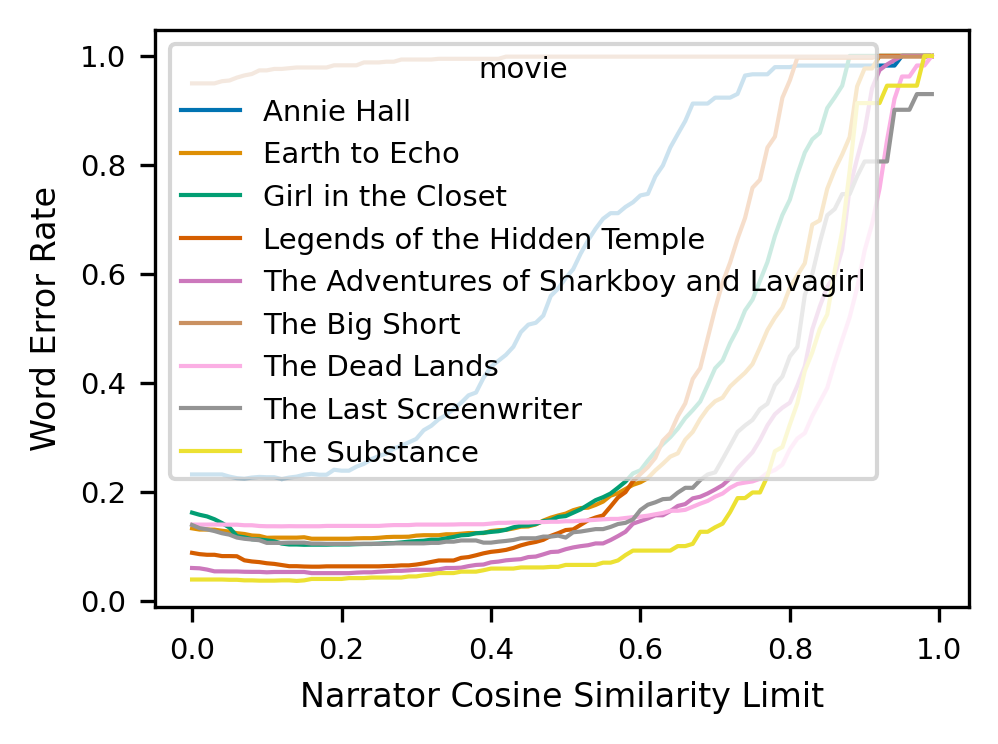

In [21]:
results_df = pd.DataFrame(results).sort_values(['movie', 'lim'])

sns.lineplot(results_df, x='lim', y='wer', hue='movie')
plt.ylabel('Word Error Rate')
plt.xlabel('Narrator Cosine Similarity Limit')
# plt.legend(['Annie Hall', 'The Substance', 'The Big Short'])
plt.savefig(os.path.join(plotting.output_dir, 'WER vs Cosine Similarity Limit.png'), bbox_inches='tight')

In [18]:
weights = np.array(word_counts) / sum(word_counts)
avg_wer = (results_df[results_df.lim.eq(narr_cosine_sim_lim)]['wer'].values * weights).sum().round(4)
print(f'Average WER of Narration: {avg_wer}')

Average WER of Narration: 0.2695


In [ ]:
final_results = []

for ii, config in enumerate(config_list):
    logging.info(f'NEW CONFIG RUN: \t{ii} / {len(config_list)}')
    for movie_name in movies:
        # da.wipe_movie_files(movie_name)
        vad_df_path = os.path.join(da.voice_activity_dir, f'{movie_name}-snippet-vad.parquet')
        seg_df_path = os.path.join(da.diarization_dir, f'{movie_name}-snippet-diarization.parquet')
        curr_transcript_fp = os.path.join(da.transcript_dir, f'{movie_name}-snippet-transcript.parquet')
        wav_filepath = os.path.join(da.trans_mp3_dir, f'{movie_name}_speech_only-snippet.wav')
    
        use_vad = config['use_vad']
        silero_threshold = config['silero_threshold']
        whisper_model = config['whisper_model']
        cosine_sim_lim = config['cosine_sim_lim']
        whisper_config['beam_size'] = config['beam_size']
        whisper_config['no_speech_threshold'] = config['no_speech_threshold']
        whisper_config['condition_on_previous_text'] = config['condition_on_previous_text']
        min_seg_sec = config['min_seg_sec']
        
        # stt.apply_pyannote_vad_to_wav(mp3_filename, wav_filepath, vad_df_path, device, credits_df)
        # stt.apply_silero_vad_to_wav(mp3_filename, wav_filepath, vad_df_path, silero_threshold=silero_threshold, credits_df=credits_df)
        # stt.apply_diarization(movie_name, wav_filepath, diarization_model, seg_df_path, device)
        # stt.add_pyannote_cosine_sim(seg_df_path, wav_filepath, min_seg_sec=min_seg_sec, device=device)
        stt.transcribe_segments(curr_transcript_fp, seg_df_path, wav_filepath, whisper_model, whisper_config, narr_cosine_sim_lim, device)
        
        wer = da.calc_wer(movie_name)
        final_results.append({'wer': wer})
        print(final_results[-1])

INFO - 2025-10-20 18:56:52,327 - NEW CONFIG RUN: 	0 / 5


RuntimeError: Failed to load audio: ffmpeg version 6.1.1-3ubuntu5 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 13 (Ubuntu 13.2.0-23ubuntu3)
  configuration: --prefix=/usr --extra-version=3ubuntu5 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --disable-omx --enable-gnutls --enable-libaom --enable-libass --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgme --enable-libgsm --enable-libharfbuzz --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx265 --enable-libxml2 --e

In [7]:
vad_df_path = os.path.join(da.voice_activity_dir, f'{movie_name}-snippet-vad.parquet')
seg_df_path = os.path.join(da.diarization_dir, f'{movie_name}-snippet-diarization.parquet')
curr_transcript_fp = os.path.join(da.transcript_dir, f'{movie_name}-snippet-transcript.parquet')
wav_filepath = os.path.join(da.trans_mp3_dir, f'{movie_name}_speech_only-snippet.wav')

vad_df = pd.read_parquet(vad_df_path)
seg_df = pd.read_parquet(seg_df_path)

In [10]:
seg_df_path = os.path.join(da.diarization_dir, f'{movie_name}-snippet-diarization.parquet')
seg_df = pd.read_parquet(seg_df_path)

In [20]:
movie_name = 'The Big Short'
curr_transcript_fp = os.path.join(da.transcript_dir, f'{movie_name}-snippet-transcript.parquet')
trans_df = pd.read_parquet(curr_transcript_fp)
trans_df = trans_df[trans_df['text'].ne(' Thank you.')]
trans_txt = ''.join(trans_df.text.str.replace('[\.,"\?!]', '', regex=True)).lower().replace('-', ' ')

with open(os.path.join(da.manual_transcript_dir, f'{movie_name}.txt')) as fileobj:
    raw_txt = fileobj.read()
ref_txt = re.sub('[\.,"\?!:]', '', raw_txt).lower().replace('-', ' ').replace('\n', ' ')

stt.visualise_wer_differences(trans_txt, ref_txt)
wer.compute(predictions=[trans_txt], references=[ref_txt])

flying stars skim across|considering treasury bonds and utility stocks in decades in this country and perhaps the end of an era in american business can you just go home you have a lake towards a distinctive pyramid like mountain with a snow covered peak the stars form an arch over the mountain paramount a viacom company a rift in the shape of an elongated letter r forms in darkness light pours through then the r solidifies and becoming metallic reflecting light regency white letters in a black rectangle plan b words appear based on a true story|very nice haircut did you think it ain't|was strange when tech bubble burst in 2001 and the housing market in san jose the tech capital of the world yeah what you|do you think i'm in commodities overview in men's perfectness i'll see you next time michael how are you guy great michael whenever you find something we'll see you next time i'll see you next time no no no no no no no no no stocks i wanna short the housing market really but the housi

0.9496021220159151